In [1]:
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns

import matplotlib.pyplot as plt
import altair as at

plt.style.use('fivethirtyeight')

from SSA2 import SSAv3


%matplotlib inline

In [2]:
data105 = pd.read_csv('105v2.csv', parse_dates=True, index_col='DateTime',encoding="windows-1252") # или 106.csv
# fig = px.line(data105, x='DateTime', y='Tmean', range_x=['2016-07-01','2016-12-31'])

data105.head(5)

,AffinityIndex,SerialNumber,H,Tmean,WmeanH,WindDirectionH(Â°),WminH,WmaxH,WmeanV,AtmosphericPressure,RelativeHumidity,TdewPoint(Â°C),WaterVaporElasticity,AbsolutusHumidity,DensityofAir,SpeedofSoundinAir
DateTime,,,,,,,,,,,,,,,,
2017-07-22 00:01:00,6,12427AMK-03,15,15.86,0.20,94.53,0.01,0.44,-0.13,750.45,100.0,15.86,17.99,14.53,1.1954,342.12
2017-07-22 00:02:00,6,12427AMK-03,15,15.88,0.28,104.28,0.15,0.53,-0.19,750.45,100.0,15.88,18.01,14.55,1.1953,342.14
2017-07-22 00:03:00,6,12427AMK-03,15,15.87,0.23,68.53,0.11,0.36,-0.19,750.45,100.0,15.87,17.99,14.54,1.1954,342.13
2017-07-22 00:04:00,6,12427AMK-03,15,15.95,0.17,47.04,0.01,0.33,-0.18,750.45,100.0,15.95,18.09,14.62,1.1950,342.18
2017-07-22 00:05:00,6,12427AMK-03,15,16.01,0.06,11.99,0.01,0.22,-0.19,750.45,100.0,16.01,18.16,14.68,1.1947,342.22


In [3]:
del data105['AffinityIndex'] 
del data105['SerialNumber'] 
del data105['H'] 
# del data105['WminH'] 
# del data105['WmaxH'] 
# del data105['WindDirectionH(Â°)'] 
# del data105['TdewPoint(Â°C)'] 
# del data105['WaterVaporElasticity'] 
# del data105['AbsolutusHumidity'] 
# del data105['DensityofAir'] 
# del data105['SpeedofSoundinAir'] 

In [4]:
data105.head(5)

,Tmean,WmeanH,WindDirectionH(Â°),WminH,WmaxH,WmeanV,AtmosphericPressure,RelativeHumidity,TdewPoint(Â°C),WaterVaporElasticity,AbsolutusHumidity,DensityofAir,SpeedofSoundinAir
DateTime,,,,,,,,,,,,,
2017-07-22 00:01:00,15.86,0.20,94.53,0.01,0.44,-0.13,750.45,100.0,15.86,17.99,14.53,1.1954,342.12
2017-07-22 00:02:00,15.88,0.28,104.28,0.15,0.53,-0.19,750.45,100.0,15.88,18.01,14.55,1.1953,342.14
2017-07-22 00:03:00,15.87,0.23,68.53,0.11,0.36,-0.19,750.45,100.0,15.87,17.99,14.54,1.1954,342.13
2017-07-22 00:04:00,15.95,0.17,47.04,0.01,0.33,-0.18,750.45,100.0,15.95,18.09,14.62,1.1950,342.18
2017-07-22 00:05:00,16.01,0.06,11.99,0.01,0.22,-0.19,750.45,100.0,16.01,18.16,14.68,1.1947,342.22


In [5]:
data105.interpolate(method='linear', inplace=True)


In [6]:
cor_data = (data105.drop(columns=['Tmean'])
              .corr().stack()
              .reset_index()     # The stacking results in an index on the correlation values, we need the index as normal columns for Altair
              .rename(columns={0: 'correlation', 'level_0': 'variable', 'level_1': 'variable2'}))
cor_data['correlation_label'] = cor_data['correlation'].map('{:.2f}'.format)  # Round to 2 decimal
cor_data.head()

,variable,variable2,correlation,correlation_label
0,WmeanH,WmeanH,1.000000,1.00
1,WmeanH,WindDirectionH(Â°),0.018650,0.02
2,WmeanH,WminH,0.237609,0.24
3,WmeanH,WmaxH,0.899471,0.90
4,WmeanH,WmeanV,0.346647,0.35


In [7]:
base = at.Chart(cor_data).encode(
    x='variable2:O',
    y='variable:O'    
)

# Text layer with correlation labels
# Colors are for easier readability
text = base.mark_text().encode(
    text='correlation_label',
    color=at.condition(
        at.datum.correlation > 0.5, 
        at.value('white'),
        at.value('black')
    )
)

# The correlation heatmap itself
cor_plot = base.mark_rect().encode(
    color='correlation:Q'
)

cor_plot + text # The '+' means overlaying the text and rect layer

alt.LayerChart(...)

In [8]:
#pd.set_option('display.max_rows', 500)

per_temp105 = data105['Tmean']  #24     48 ТЕМПЕРАТУРА

per_temp105

DateTime
2017-07-22 00:01:00    15.86
2017-07-22 00:02:00    15.88
2017-07-22 00:03:00    15.87
2017-07-22 00:04:00    15.95
2017-07-22 00:05:00    16.01
                       ...  
2020-04-09 23:55:00     0.46
2020-04-09 23:56:00     0.50
2020-04-09 23:57:00     0.58
2020-04-09 23:58:00     0.48
2020-04-09 23:59:00     0.49
Name: Tmean, Length: 1186390, dtype: float64

AttributeError: 'DataFrame' object has no attribute 'ix'

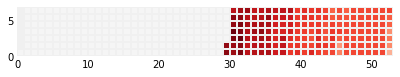

In [15]:
import calmap
calmap.yearplot(per_temp105, monthticks=3, daylabels='MTWTFSS',
                dayticks=[0, 2, 4, 6])


In [ ]:
# Выбор периода с выбранной частотой
# 1=1min 2=2min, 10=10min, 60=1hour, 720=12hour, 1440=1day, 10080=1week, 44640=1month

# 2019-04-09 01:01:00':'2020-04-04 01:01:00
from IPython.display import display

period2=data105['2017-07-22 00:01:00':'2020-04-04 01:01:00'][::1]
per_temp2 = period2['Tmean']  #24     48

display(per_temp2.head(5))
display(per_temp2.tail(5))

In [ ]:
desc = per_temp2.describe()
desc.loc['count'] = desc.loc['count'].astype(int).astype(str)
print(desc)

In [ ]:
plt.figure()
per_temp2.plot(figsize=[20,7])
#per_temp2.plot(style='k.')
plt.title('Температура выбранного периода №1', fontsize=20)
plt.grid(True)
plt.ylabel('Температура ($^oC$)',fontsize=15)
plt.xlabel('Период',fontsize=15)
plt.legend()

In [ ]:
#pd.set_option('display.max_rows', 500)

per_temp105 = data105['Tmean']  #24     48 ТЕМПЕРАТУРА

per_temp105

In [ ]:
means105 = data105.groupby(pd.Grouper(freq='D')).mean()  # ПЕРИОД
means105

In [ ]:
#pd.set_option('display.max_rows', 500)

per_temp105 = means105['Tmean']  #24     48 ТЕМПЕРАТУРА

per_temp105

In [ ]:
per_temp105.interpolate(method='linear', inplace=True)


In [ ]:
# Using plotly.express
import plotly.express as px

import pandas as pd

fig = px.line(per_temp105, title='Температура выбранного периода ст. 105')
fig.show()